**Візуальні ознаки**



In [3]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [15, 10]

In [131]:
# завантаження
img = cv2.imread('C:/Users/User/Downloads/document.jpg')

# перевірка
if img is None:
    print("Зображення не знайдено")
else:
    print("Зображення завантажено")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

Зображення завантажено


(<Axes: title={'center': 'Gray'}>,
 Text(0.5, 1.0, 'Gray'))

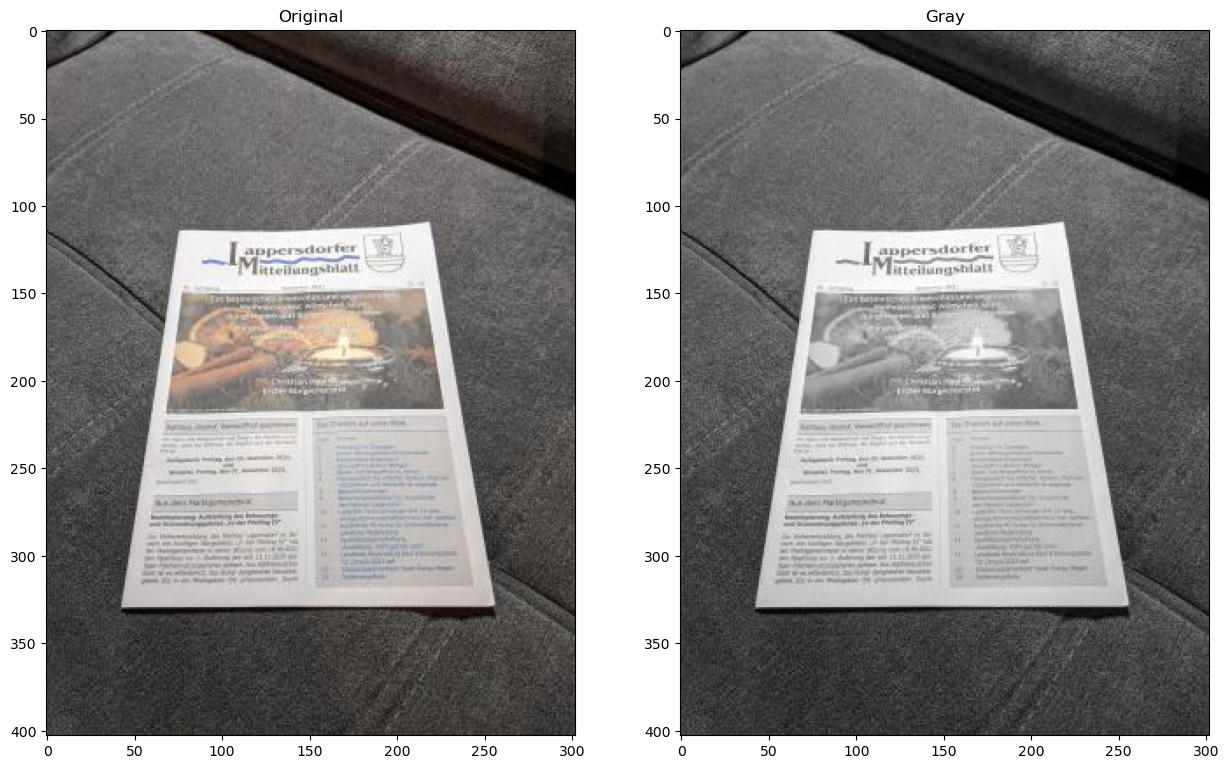

In [93]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# нормалізація
gray = np.float32(gray) / 255

rows, cols = gray.shape

plt.subplot(121), plt.imshow(img_rgb), plt.title("Original")
plt.subplot(122), plt.imshow(gray, cmap='gray'), plt.title("Gray")

*Harris Corner Detector*

Детектор Гарріса дозволяє знаходити області з різкою зміною інтенсивності (кути).


(<Axes: title={'center': 'Cornerness'}>,
 Text(0.5, 1.0, 'Cornerness'))

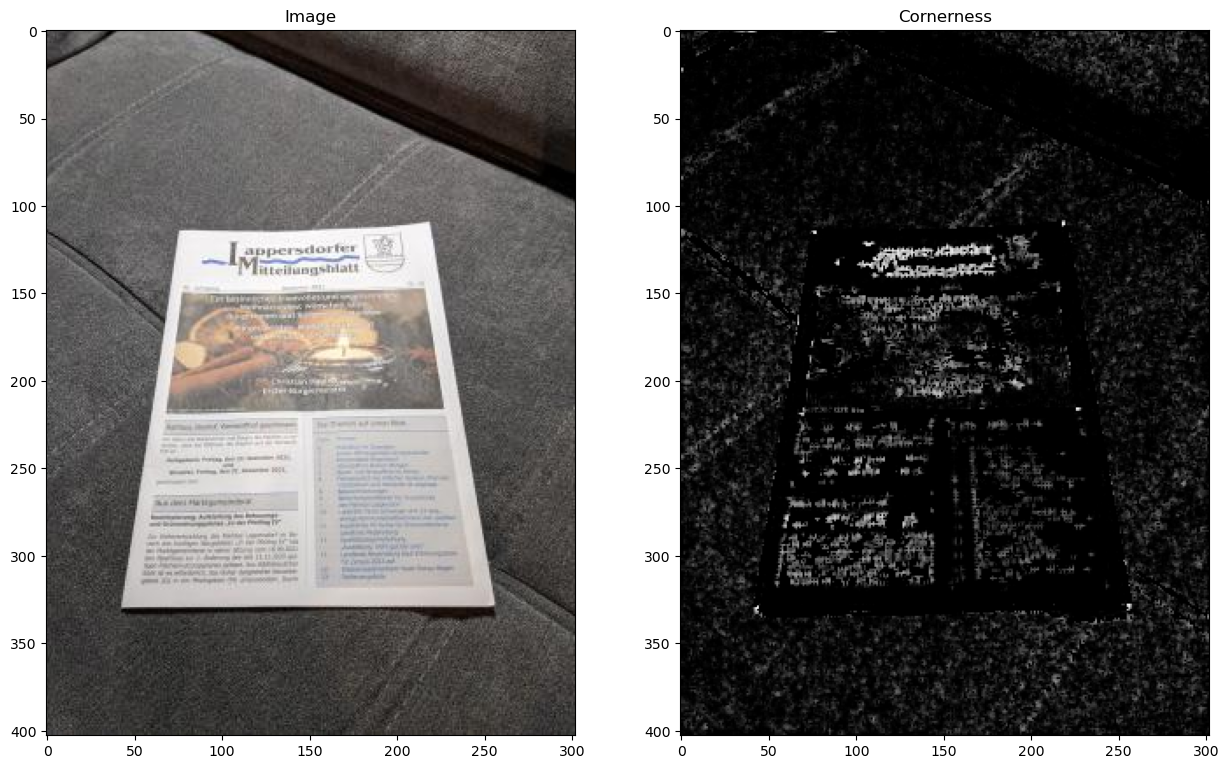

In [96]:
# Harris
cornerness = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# прибираємо від’ємні значення
cornerness[cornerness < 0] = 0

# логарифм
cornerness = np.log(cornerness + 1e-6)

plt.subplot(121), plt.imshow(img_rgb), plt.title("Image")
plt.subplot(122), plt.imshow(cornerness, cmap='gray'), plt.title("Cornerness")

*Ініціалізація*

In [129]:
# пороги
th_top_left, th_top_right = -1e6, -1e6
th_bottom_left, th_bottom_right = -1e6, -1e6

# координати
opt_top_left, opt_top_right = None, None
opt_bottom_left, opt_bottom_right = None, None

# розмір квадрата
quad_size = 10

*Пошук 4 кутів (DESCRIPTOR)*

Було розроблено власний дескриптор на основі аналізу яскравості квадрантів.
Це дозволило відфільтрувати зайві точки та залишити лише ті, які відповідають кутам документа.


In [117]:
for r in range(quad_size, rows-quad_size):
    for c in range(quad_size, cols-quad_size):
        
        # фільтр по cornerness
        if cornerness[r, c] < -6:
            continue
        
        # беремо блок
        block = 255 * gray[r-quad_size:r+quad_size+1, c-quad_size:c+quad_size+1]
        
        # квадранти
        quad_top_left = block[0:quad_size, 0:quad_size]
        quad_top_right = block[0:quad_size, quad_size:2*quad_size]
        quad_bottom_left = block[quad_size:2*quad_size, 0:quad_size]
        quad_bottom_right = block[quad_size:2*quad_size, quad_size:2*quad_size]

        # TOP LEFT
        desc_tl = np.mean(quad_bottom_right) - \
                  np.mean(quad_top_left) - np.mean(quad_top_right) - np.mean(quad_bottom_left)

        if desc_tl > th_top_left:
            th_top_left = desc_tl
            opt_top_left = (c, r)

        # TOP RIGHT
        desc_tr = np.mean(quad_bottom_left) - \
                  np.mean(quad_top_left) - np.mean(quad_top_right) - np.mean(quad_bottom_right)

        if desc_tr > th_top_right:
            th_top_right = desc_tr
            opt_top_right = (c, r)

        # BOTTOM LEFT
        desc_bl = np.mean(quad_top_right) - \
                  np.mean(quad_top_left) - np.mean(quad_bottom_left) - np.mean(quad_bottom_right)

        if desc_bl > th_bottom_left:
            th_bottom_left = desc_bl
            opt_bottom_left = (c, r)

        # BOTTOM RIGHT
        desc_br = np.mean(quad_top_left) - \
                  np.mean(quad_top_right) - np.mean(quad_bottom_left) - np.mean(quad_bottom_right)

        if desc_br > th_bottom_right:
            th_bottom_right = desc_br
            opt_bottom_right = (c, r)

*Відображення результатів*

Text(0.5, 1.0, 'Cornerness')

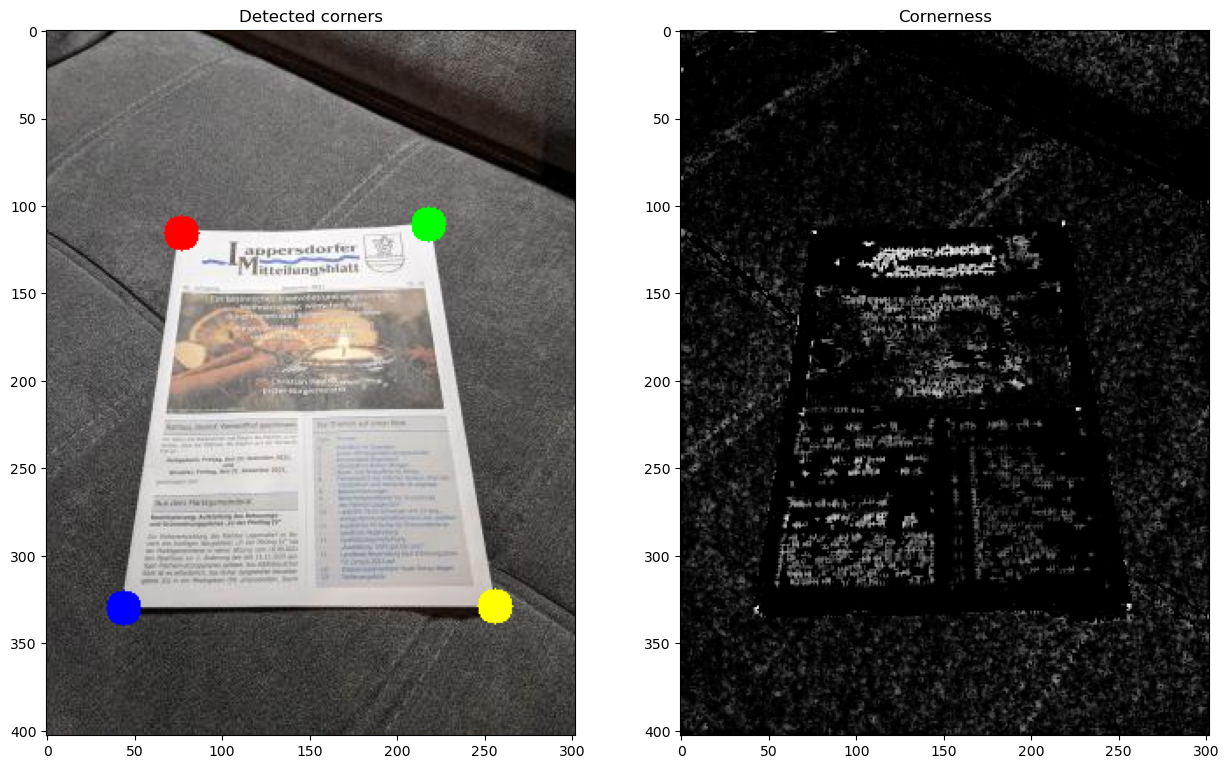

In [120]:
out = img_rgb.copy()

# малюємо точки
out = cv2.circle(out, opt_top_left, 10, (255,0,0), -1)
out = cv2.circle(out, opt_top_right, 10, (0,255,0), -1)
out = cv2.circle(out, opt_bottom_left, 10, (0,0,255), -1)
out = cv2.circle(out, opt_bottom_right, 10, (255,255,0), -1)

plt.subplot(121), plt.imshow(out)
plt.title("Detected corners")

plt.subplot(122), plt.imshow(cornerness, cmap='gray')
plt.title("Cornerness")

In [107]:
# Перевірка
print("Top-left:", opt_top_left)
print("Top-right:", opt_top_right)
print("Bottom-left:", opt_bottom_left)
print("Bottom-right:", opt_bottom_right)

Top-left: (76, 115)
Top-right: (219, 111)
Bottom-left: (44, 330)
Bottom-right: (255, 329)


**Вис**
У лабораторній роботі було досліджено детектор кутів Гарріса та реалізовано власний дескриптор для знаходження кутів документа. Показано, що сам по собі детектор знаходить багато зайвих точок, тому для отримання точного результату необхідна додаткова фільтрація.

Розроблений дескриптор дозволив успішно виділити саме 4 кути документа. Якість результату залежить від параметрів алгоритму, контрасту зображення та його роздільної здатності.

Отже, комбінування класичних методів комп’ютерного зору з власними підходами дозволяє ефективно вирішувати практичні задачі обробки зображень.